<a href="https://colab.research.google.com/github/TechnoAceX/Colab/blob/main/ML_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Practical 1: Demonstrate various data pre-processing techniques for a given dataset.

🔹 Original Data Sample:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

🔹 Selected Top 2 Features: ['petal length (cm)' 'petal width (cm)']


<ipython-input-1-f07857250b64>:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['sepal length (cm)'].fillna(df['sepal length (cm)'].mean(), inplace=True)


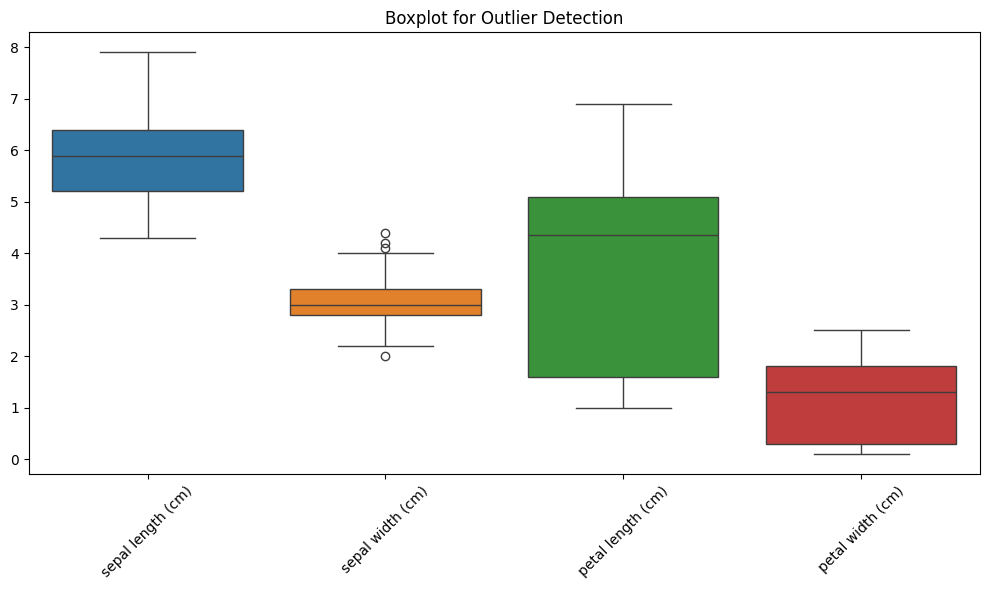


🔹 Training Set Shape: (120, 4)
🔹 Testing Set Shape: (30, 4)


In [ ]:
# Importing necessary libraries
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
import matplotlib.pyplot as plt
import seaborn as sns

# Load Iris dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target

# Introduce some missing values artificially for demonstration
df.loc[5:10, 'sepal length (cm)'] = np.nan

print("🔹 Original Data Sample:")
print(df.head())

# 1️⃣ Handling Missing Values
df['sepal length (cm)'].fillna(df['sepal length (cm)'].mean(), inplace=True)

# 2️⃣ Encoding Categorical Variables
# Iris target is already numeric. If not, we could use LabelEncoder or OneHotEncoder
# Example (if needed):
# label_encoder = LabelEncoder()
# df['target'] = label_encoder.fit_transform(df['target'])

# 3️⃣ Feature Scaling
scaler_std = StandardScaler()
df_scaled = df.copy()
df_scaled[iris.feature_names] = scaler_std.fit_transform(df[iris.feature_names])

# Also showing Min-Max Scaling
scaler_minmax = MinMaxScaler()
df_minmax = df.copy()
df_minmax[iris.feature_names] = scaler_minmax.fit_transform(df[iris.feature_names])

# 4️⃣ Feature Selection (Select top 2 features)
X = df[iris.feature_names]
y = df['target']
selector = SelectKBest(score_func=f_classif, k=2)
X_new = selector.fit_transform(X, y)
selected_features = np.array(iris.feature_names)[selector.get_support()]
print("\n🔹 Selected Top 2 Features:", selected_features)

# 5️⃣ Outlier Detection (Visual using Boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[iris.feature_names])
plt.title("Boxplot for Outlier Detection")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 6️⃣ Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("\n🔹 Training Set Shape:", X_train.shape)
print("🔹 Testing Set Shape:", X_test.shape)


### Practical 2: Implement Simple and Multiple Linear Regression Models.

In [ ]:
# Import required libraries
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Target'] = data.target

print("🔹 Sample Dataset:")
print(df.head())

# 1️⃣ SIMPLE LINEAR REGRESSION (Using only 'MedInc')
X_simple = df[['MedInc']]
y = df['Target']

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_simple, y, test_size=0.2, random_state=42)

model_simple = LinearRegression()
model_simple.fit(X_train_s, y_train_s)
y_pred_s = model_simple.predict(X_test_s)

print("\n📈 Simple Linear Regression:")
print(f"Coefficient: {model_simple.coef_[0]}")
print(f"Intercept: {model_simple.intercept_}")
print(f"MSE: {mean_squared_error(y_test_s, y_pred_s)}")
print(f"R² Score: {r2_score(y_test_s, y_pred_s)}")

# 2️⃣ MULTIPLE LINEAR REGRESSION (Using all features)
X_multi = df.drop('Target', axis=1)

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y, test_size=0.2, random_state=42)

model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_m)
y_pred_m = model_multi.predict(X_test_m)

print("\n📊 Multiple Linear Regression:")
print(f"Coefficients: {model_multi.coef_}")
print(f"Intercept: {model_multi.intercept_}")
print(f"MSE: {mean_squared_error(y_test_m, y_pred_m)}")
print(f"R² Score: {r2_score(y_test_m, y_pred_m)}")

🔹 Sample Dataset:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Target  
0    -122.23   4.526  
1    -122.22   3.585  
2    -122.24   3.521  
3    -122.25   3.413  
4    -122.25   3.422  

📈 Simple Linear Regression:
Coefficient: 0.4193384939381271
Intercept: 0.4445972916907879
MSE: 0.7091157771765549
R² Score: 0.45885918903846656

📊 Multiple Linear Regression:
Coefficients: [ 4.48674910e-01  9.72425752e-03 -1.23323343e-01  7.83144907e-01
 -2.02962058e-06 -3.52631849e-03 -4.19792487e-01 -4.33708065e-01]
Intercept: -37.02327770606409
MSE: 0.5558915986952444
R² Score: 0.

### Practical 3 Develop Logistic Regression Model for a given dataset.

In [ ]:
# Import required libraries
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print("🔹 Dataset Sample:")
print(df.head())

# Independent (X) and Dependent (y) variables
X = df.drop('target', axis=1)
y = df['target']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the Logistic Regression model
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
acc = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("\n✅ Logistic Regression Model Evaluation:")
print(f"Accuracy Score: {acc}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(report)

🔹 Dataset Sample:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area

### Practical 4: Develop Decision Tree Classification model for a given dataset and use it to classify a new sample.

In [ ]:
# Import necessary libraries
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load dataset
data = load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print("🔹 Sample Data:")
print(df.head())

# Features and Target
X = df.drop('target', axis=1)
y = df['target']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the model
model = DecisionTreeClassifier(criterion='gini', random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("\n✅ Model Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 🔍 Classify a new sample
# Example: [sepal length, sepal width, petal length, petal width]
new_sample = [[5.1, 3.5, 1.4, 0.2]]  # Expected: Iris-setosa
predicted_class_index = model.predict(new_sample)[0]
predicted_class_name = data.target_names[predicted_class_index]

print("\n🔎 New Sample Classification:")
print("Sample:", new_sample)
print("Predicted Class:", predicted_class_name)

🔹 Sample Data:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

✅ Model Evaluation:
Accuracy: 1.0

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00      

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


### Practical 5: Implement the naive Bayesian classifier for a sample training data set stored as a .CSV file. Compute the accuracy of the classifier, considering few test data sets.

In [ ]:
import kagglehub
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# ⬇️ Download Iris dataset
path = kagglehub.dataset_download("uciml/iris")
print("Path to dataset files:", path)

data = pd.read_csv(f"{path}/Iris.csv")

# Drop Id column if present
data = data.drop('Id', axis=1)

# 🎯 Features and Target
X = data.drop('Species', axis=1)
y = data['Species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n Accuracy of the model on the test set: {accuracy:.2f}")

# 📊 Show first 5 predictions
test_data_points = X_test.head(5)
actual_values = y_test.head(5)
predicted_values = y_pred[:5]

print("\n🔎 First 5 Test Predictions:")
for i in range(len(test_data_points)):
    print(f"\nTest Data {i+1}:")
    print(f"Actual Species: {actual_values.iloc[i]}")
    print(f"Predicted Species: {predicted_values[i]}")

Path to dataset files: /kaggle/input/iris

 Accuracy of the model on the test set: 1.00

🔎 First 5 Test Predictions:

Test Data 1:
Actual Species: Iris-versicolor
Predicted Species: Iris-versicolor

Test Data 2:
Actual Species: Iris-setosa
Predicted Species: Iris-setosa

Test Data 3:
Actual Species: Iris-virginica
Predicted Species: Iris-virginica

Test Data 4:
Actual Species: Iris-versicolor
Predicted Species: Iris-versicolor

Test Data 5:
Actual Species: Iris-versicolor
Predicted Species: Iris-versicolor


### Practical 6: Implement Naive Bayes theorem to classify the English text.

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# Sample data: text messages and their respective categories (sports, politics, tech)
texts = [
    "The match was intense and the players gave their best",        # sports
    "The government passed a new law today",                         # politics
    "Python is widely used in machine learning projects",            # tech
    "The football team won the championship",                        # sports
    "Elections will be held next month across the country",          # politics
    "Google released a new AI model for translation",                # tech
    "A new stadium was inaugurated for cricket lovers",              # sports
    "Parliament members debated the new education policy",           # politics
    "AI and data science are the future of technology",              # tech
    "The basketball game was thrilling and exciting",               # sports (Added more sports)
    "The Prime Minister held a press conference today",              # politics (Added more politics)
    "AI is revolutionizing the healthcare industry",                 # tech (Added more tech)
    "The tennis tournament was exciting",                            # sports (Added more sports)
    "New laws are being passed to regulate data privacy",            # politics (Added more politics)
    "Quantum computing is a hot topic in tech",                      # tech (Added more tech)
]

labels = [
    "sports", "politics", "tech",
    "sports", "politics", "tech",
    "sports", "politics", "tech",
    "sports", "politics", "tech",
    "sports", "politics", "tech"
]

# Convert the data into a pandas DataFrame
data = pd.DataFrame({'text': texts, 'label': labels})

# Split the data into features (X) and target (y)
X = data['text']
y = data['label']

# 🔀 Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 🔢 Vectorization using TF-IDF
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# 🤖 Train the Naive Bayes classifier (MultinomialNB)
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

# 🔍 Predict the test set
y_pred = model.predict(X_test_tfidf)

# 🎯 Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the Naive Bayes classifier on the test set: {accuracy:.2f}")

# 📊 Show first 5 predictions
test_data_points = X_test.head(5)
actual_values = y_test.head(5)
predicted_values = y_pred[:5]

print("\n🔎 First 5 Test Predictions:")
for i in range(len(test_data_points)):
    print(f"\nTest Data {i+1}:")
    print(f"Actual Category: {actual_values.iloc[i]}")
    print(f"Predicted Category: {predicted_values[i]}")


Accuracy of the Naive Bayes classifier on the test set: 0.67

🔎 First 5 Test Predictions:

Test Data 1:
Actual Category: sports
Predicted Category: sports

Test Data 2:
Actual Category: tech
Predicted Category: tech

Test Data 3:
Actual Category: sports
Predicted Category: politics


### Practical 7: Build KNN Classification model for a given dataset.

In [ ]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load the Iris dataset (you can replace it with your own dataset)
iris = load_iris()

# Convert to a pandas DataFrame
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features (important for KNN as it relies on distances)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the KNN model (you can change the number of neighbors)
knn = KNeighborsClassifier(n_neighbors=3)

# Train the KNN model
knn.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = knn.predict(X_test_scaled)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the KNN classifier on the test set: {accuracy:.2f}")

# Show predictions for the first 5 test samples
test_data_points = X_test.head(5)
actual_values = y_test.head(5)
predicted_values = y_pred[:5]

print("\n🔎 First 5 Test Predictions:")
for i in range(len(test_data_points)):
    print(f"\nTest Data {i+1}:")
    print(f"Actual Label: {iris.target_names[actual_values.iloc[i]]}")
    print(f"Predicted Label: {iris.target_names[predicted_values[i]]}")


Accuracy of the KNN classifier on the test set: 1.00

🔎 First 5 Test Predictions:

Test Data 1:
Actual Label: versicolor
Predicted Label: versicolor

Test Data 2:
Actual Label: setosa
Predicted Label: setosa

Test Data 3:
Actual Label: virginica
Predicted Label: virginica

Test Data 4:
Actual Label: versicolor
Predicted Label: versicolor

Test Data 5:
Actual Label: versicolor
Predicted Label: versicolor


### Practical 8: Implement Random forest ensemble method on a given dataset.

In [ ]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load the Iris dataset (you can replace it with your own dataset)
iris = load_iris()

# Convert to a pandas DataFrame
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features (important for many algorithms including Random Forest)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the Random Forest classifier
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the Random Forest model
random_forest.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = random_forest.predict(X_test_scaled)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the Random Forest classifier on the test set: {accuracy:.2f}")

# Show predictions for the first 5 test samples
test_data_points = X_test.head(5)
actual_values = y_test.head(5)
predicted_values = y_pred[:5]

print("\n🔎 First 5 Test Predictions:")
for i in range(len(test_data_points)):
    print(f"\nTest Data {i+1}:")
    print(f"Actual Label: {iris.target_names[actual_values.iloc[i]]}")
    print(f"Predicted Label: {iris.target_names[predicted_values[i]]}")

Accuracy of the Random Forest classifier on the test set: 1.00

🔎 First 5 Test Predictions:

Test Data 1:
Actual Label: versicolor
Predicted Label: versicolor

Test Data 2:
Actual Label: setosa
Predicted Label: setosa

Test Data 3:
Actual Label: virginica
Predicted Label: virginica

Test Data 4:
Actual Label: versicolor
Predicted Label: versicolor

Test Data 5:
Actual Label: versicolor
Predicted Label: versicolor


### Practical 9: Show the implementation of K-Means clustering Algorithm.

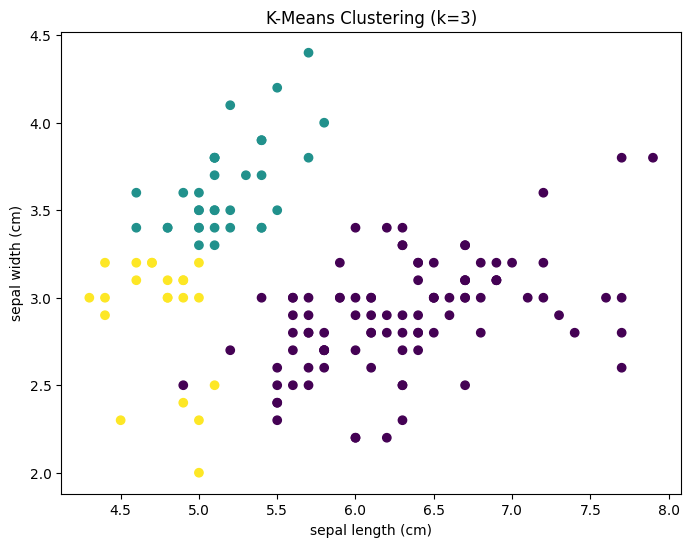

Cluster Centers:
[[ 0.57100359 -0.37176778  0.69111943  0.66315198]
 [-0.81623084  1.31895771 -1.28683379 -1.2197118 ]
 [-1.32765367 -0.373138   -1.13723572 -1.11486192]]


In [ ]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load the Iris dataset (you can replace it with your own dataset)
iris = load_iris()

# Convert to a pandas DataFrame
X = pd.DataFrame(iris.data, columns=iris.feature_names)

# Standardize the data (important for clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply KMeans with a range of cluster numbers to find the optimal k using the Elbow Method
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# From the Elbow method, choose an optimal k (typically where the inertia starts to level off)
optimal_k = 3

# Now, apply KMeans with the chosen k
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
kmeans.fit(X_scaled)

# Get the cluster labels for each data point
labels = kmeans.labels_

# Add the cluster labels to the original data
X['Cluster'] = labels

# Visualize the clustering result in 2D using the first two features
plt.figure(figsize=(8, 6))
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=labels, cmap='viridis', marker='o')
plt.title(f'K-Means Clustering (k={optimal_k})')
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.show()

# Print the cluster centers
print("Cluster Centers:")
print(kmeans.cluster_centers_)

### Practical 10: Write a program to implement k-Nearest Neighbour algorithm to classify the iris data set. Print both correct and wrong predictions.



In [ ]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load the Iris dataset
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target)

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the K-Nearest Neighbour classifier (k=3)
knn = KNeighborsClassifier(n_neighbors=3)

# Train the model
knn.fit(X_train, y_train)

# Predict the classes for the test set
y_pred = knn.predict(X_test)

# Compute accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the KNN model: {accuracy * 100:.2f}%")

# Print correct and wrong predictions
print("\nCorrect Predictions:")
for i in range(len(y_pred)):
    if y_pred[i] == y_test.iloc[i]:
        print(f"Test Data {i+1} - Actual: {iris.target_names[y_test.iloc[i]]}, Predicted: {iris.target_names[y_pred[i]]}")

print("\nWrong Predictions:")
for i in range(len(y_pred)):
    if y_pred[i] != y_test.iloc[i]:
        print(f"Test Data {i+1} - Actual: {iris.target_names[y_test.iloc[i]]}, Predicted: {iris.target_names[y_pred[i]]}")

Accuracy of the KNN model: 100.00%

Correct Predictions:
Test Data 1 - Actual: versicolor, Predicted: versicolor
Test Data 2 - Actual: setosa, Predicted: setosa
Test Data 3 - Actual: virginica, Predicted: virginica
Test Data 4 - Actual: versicolor, Predicted: versicolor
Test Data 5 - Actual: versicolor, Predicted: versicolor
Test Data 6 - Actual: setosa, Predicted: setosa
Test Data 7 - Actual: versicolor, Predicted: versicolor
Test Data 8 - Actual: virginica, Predicted: virginica
Test Data 9 - Actual: versicolor, Predicted: versicolor
Test Data 10 - Actual: versicolor, Predicted: versicolor
Test Data 11 - Actual: virginica, Predicted: virginica
Test Data 12 - Actual: setosa, Predicted: setosa
Test Data 13 - Actual: setosa, Predicted: setosa
Test Data 14 - Actual: setosa, Predicted: setosa
Test Data 15 - Actual: setosa, Predicted: setosa
Test Data 16 - Actual: versicolor, Predicted: versicolor
Test Data 17 - Actual: virginica, Predicted: virginica
Test Data 18 - Actual: versicolor, Pred